# 순환 신경망

## RNN(Recurrent Neural Network)   
※ 참고자료: https://davinci-ai.tistory.com/30
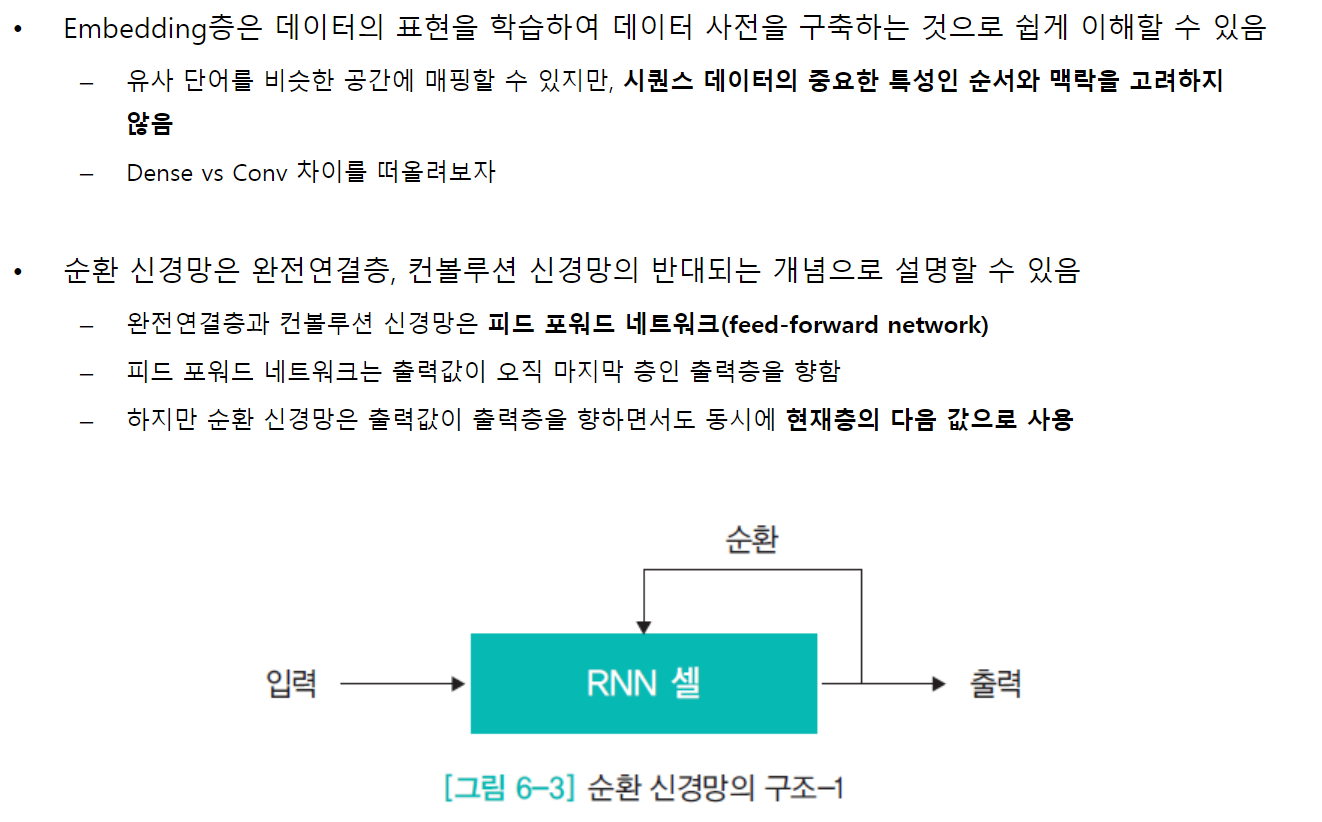

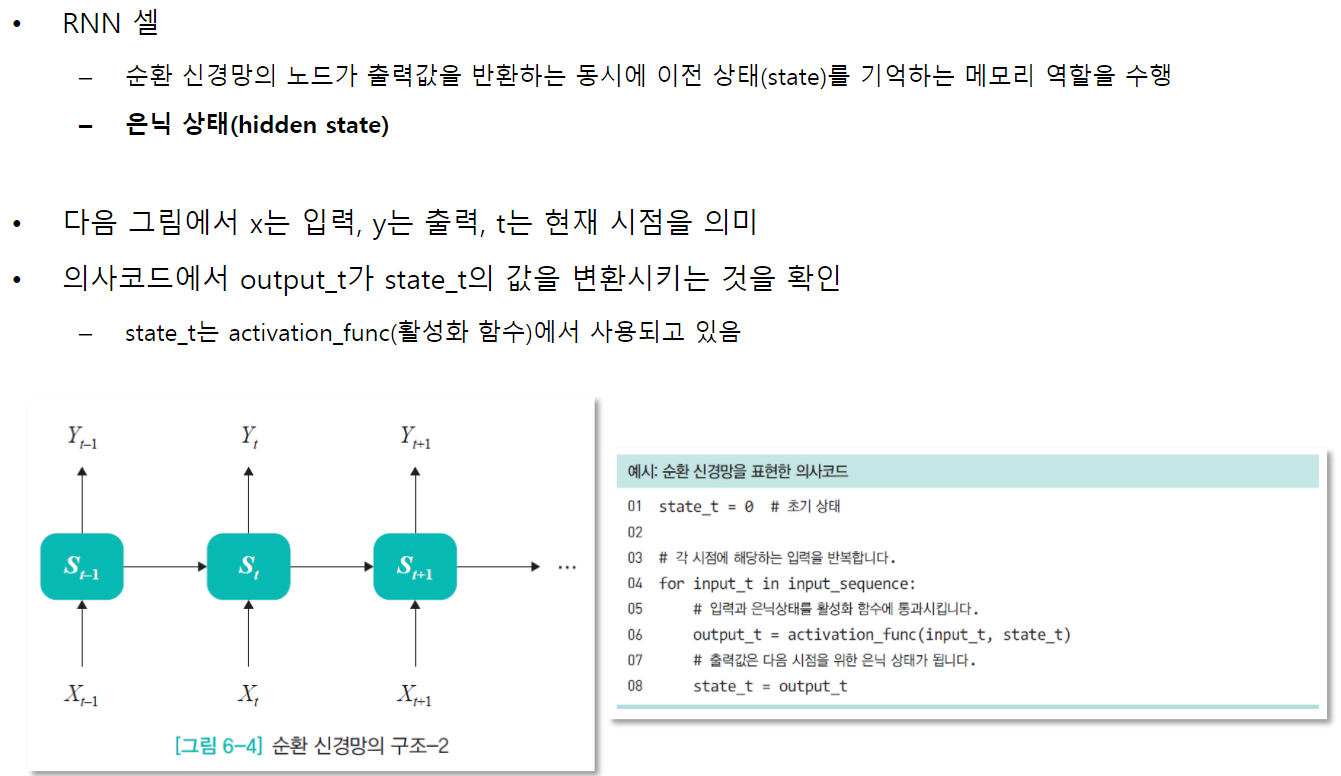

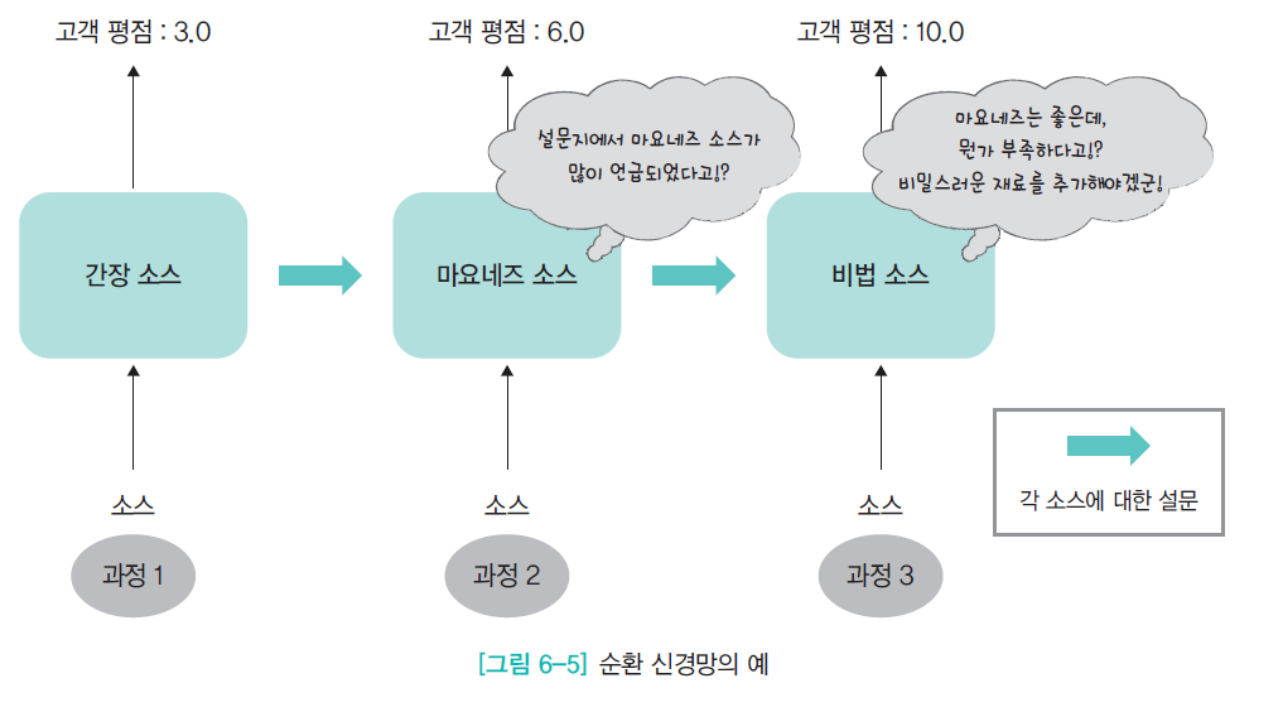

### SimpleRNN을 사용하여 모델 구성하기
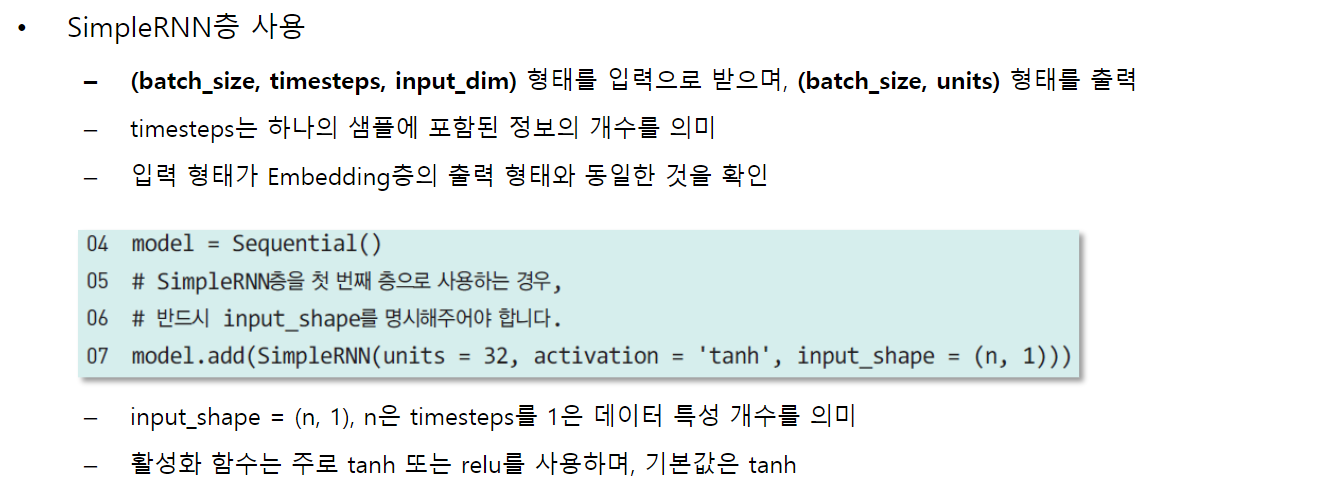

## 네이버 영화 리뷰를 이용한 감성분석(RNN)

In [2]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

데이터 받아오기(네이버 영화 리뷰)
  - label: 0 => 부정, 1 => 긍정

In [3]:
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_table(train_url).dropna(subset=["document"])
test_df  = pd.read_table(test_url).dropna(subset=["document"])

display(train_df.head())
display(test_df.head())

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


X_train, y_train, X_test, y_test 데이터 생성

In [ ]:
X_train = train_df["document"].astype(str).tolist()
y_train = train_df["label"].values

X_train[:5]

In [9]:
X_test = test_df["document"].astype(str).tolist()
y_test = test_df["label"].values

- 데이터 정제

In [ ]:
def clean_text(text):
  txt = re.sub(r"[^가-힣a-zA-Z]", " ", text)
  txt = re.sub(r"\s+", " ", txt).strip()
  return txt

train_txt = [clean_text(text) for text in X_train]
test_txt  = [clean_text(text) for text in X_test]

train_txt[:5]

토큰화 및 단어사전 생성 => 정수 인코딩

In [14]:
vocab_size = 20000

tokenize = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenize.fit_on_texts(train_txt)

In [ ]:
x_train = tokenize.texts_to_sequences(train_txt)
x_test  = tokenize.texts_to_sequences(test_txt)

x_train[0]

모든 문장의 길이 맞추기(Pandding)

In [16]:
max_len = 100

x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test  = pad_sequences(x_test, maxlen=max_len, padding='post')

In [ ]:
x_train[0]

학습데이터/검증데이터 분리

In [ ]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train,
                                            test_size=0.2,
                                            random_state=42)

x_tr.shape, x_val.shape

### 모델 구성

In [ ]:
tf.random.set_seed(42)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    SimpleRNN(64),          # RNN 핵심 레이어
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # 이진분류
])

In [20]:
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics = ['acc'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 모델 학습시키기

In [21]:
# 강제 종료
es = EarlyStopping(monitor="val_loss",
                   patience=10,
                   restore_best_weights=True)   # 종료후 가장 좋은 가중치 복원

# 최적의 가중치 자동 저장
cp = ModelCheckpoint("best_model.h5",
                     monitor="val_loss",
                     save_best_only=True)

In [ ]:
history = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[es, cp],
    verbose=1
)

### 예측 결과 그려보기

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

### 평가

In [27]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"NSMC Test Loss: {loss:.4f}, Test Acc: {acc:.4f}")

NSMC Test Loss: 0.4640, Test Acc: 0.7818


### 새로운 문장 예측

In [32]:
def predict_sentiment_kor(text: str):
    text = clean_text(text)
    seq = tokenize.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = float(model.predict(seq, verbose=0)[0][0])
    label = "긍정" if prob >= 0.5 else "부정"
    print(f"[{label}] prob={prob:.3f} | {text}")

In [ ]:
predict_sentiment_kor("연기가 너무 좋고 스토리도 감동적이었어요!!!!!!!")
predict_sentiment_kor("지루하고 시간 아까운 영화였습니다")

In [34]:
import joblib

joblib.dump(tokenize, "tokenizer.joblib")

['tokenizer.joblib']